# Descomposición del Desarrollo (Development Accounting)

## Modelo

$$y = A \cdot \underbrace{\left(\frac{K}{Y}\right)^{\alpha/(1-\alpha)}}_{\text{factor capital}} \cdot h \cdot e$$

donde:
- $y = \text{rgdpo}/\text{emp}$ — producto por trabajador
- $K/Y = \text{cn}/\text{rgdpo}$
- $\alpha = 1/3$
- $h = \text{hc}$ — capital humano
- $e = (\gamma\,(1-\alpha)\,y)^{\gamma}$ — factor de esfuerzo/utilización, con $\gamma \in \{0, 0.25, 0.5, 0.75, 1\}$
- $A$ — TFP calculada por residuo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Carga de datos

In [2]:
df = pd.read_excel('Datos.xlsx')
print(f'Observaciones: {len(df)} países')
df.head()

Observaciones: 141 países


,country,rgdpo,pop,emp,hc,cn,ln(A/A_us),ln(h/h_us)
0,Albania,36103.042969,2.880917,1.075898,2.964992,2.239714e+05,-1.428059,-0.234706
1,Algeria,507487.562500,43.053054,11.273454,2.383965,2.290438e+06,-0.757092,-0.452815
2,Angola,227855.718750,31.825295,16.644962,1.481984,1.299232e+06,-1.589020,-0.928198
3,Argentina,977420.562500,44.780677,20.643215,3.096804,3.183182e+06,-0.805036,-0.191209
4,Armenia,43582.574219,2.957731,0.966091,3.135995,9.324618e+04,-0.655920,-0.178634


## 2. Cálculo de variables base

In [3]:
alpha = 1/3
gammas = [0, 0.25, 0.5, 0.75, 1]

# Producto por trabajador
df['y'] = df['rgdpo'] / df['emp']

# Razón capital-producto
df['KY'] = df['cn'] / df['rgdpo']

# Factor capital: (K/Y)^{alpha/(1-alpha)}
df['factor_capital'] = df['KY'] ** (alpha / (1 - alpha))

# Capital humano
df['h'] = df['hc']

print('Variables base calculadas:')
df[['country', 'y', 'KY', 'factor_capital', 'h']].head(10)

Variables base calculadas:


,country,y,KY,factor_capital,h
0,Albania,33556.204444,6.203670,2.490717,2.964992
1,Algeria,45016.157022,4.513288,2.124450,2.383965
2,Angola,13689.170002,5.701992,2.387884,1.481984
3,Argentina,47348.271769,3.256717,1.804638,3.096804
4,Armenia,45112.287815,2.139529,1.462713,3.135995
5,Australia,106091.832660,4.298796,2.073354,3.549666
6,Austria,104983.735066,5.505755,2.346435,3.381046
7,Bahrain,103645.799578,5.298260,2.301795,2.229507
8,Bangladesh,11588.944195,3.599188,1.897153,2.101790
9,Barbados,26513.718856,8.342804,2.888391,2.846072


## 3. Descomposición para cada $\gamma$

Para $\gamma = 0$: por convención $0^0 = 1$, entonces $e = 1$.

In [4]:
results = {}

for gamma in gammas:
    res = df[['country', 'y', 'factor_capital', 'h']].copy()
    
    if gamma == 0:
        # e = (0*(1-alpha)*y)^0 = 1 por convención
        res['e'] = 1.0
    else:
        # e = (gamma * (1-alpha) * y)^gamma
        res['e'] = (gamma * (1 - alpha) * df['y']) ** gamma
    
    # A por residuo
    res['A'] = df['y'] / (res['factor_capital'] * res['h'] * res['e'])
    
    results[gamma] = res
    print(f'\n=== gamma = {gamma} ===')
    print(res[['country', 'y', 'factor_capital', 'h', 'e', 'A']].to_string(index=False))


=== gamma = 0 ===
                         country             y  factor_capital        h   e            A
                         Albania  33556.204444        2.490717 2.964992 1.0  4543.860032
                         Algeria  45016.157022        2.124450 2.383965 1.0  8888.366033
                          Angola  13689.170002        2.387884 1.481984 1.0  3868.300352
                       Argentina  47348.271769        1.804638 3.096804 1.0  8472.280823
                         Armenia  45112.287815        1.462713 3.135995 1.0  9834.684937
                       Australia 106091.832660        2.073354 3.549666 1.0 14415.211934
                         Austria 104983.735066        2.346435 3.381046 1.0 13233.126283
                         Bahrain 103645.799578        2.301795 2.229507 1.0 20196.504931
                      Bangladesh  11588.944195        1.897153 2.101790 1.0  2906.378689
                        Barbados  26513.718856        2.888391 2.846072 1.0  3225.289323
  

## 7. Descomposición de covarianza

Como $\ln y = \ln A + \ln(\text{factor capital}) + \ln h + \ln e$, se cumple:

$$\text{Var}(\ln y) = \text{Cov}(\ln y, \ln A) + \text{Cov}(\ln y, \ln\text{fc}) + \text{Cov}(\ln y, \ln h) + \text{Cov}(\ln y, \ln e)$$

La **participación** de cada componente es:

$$\theta_X = \frac{\text{Cov}(\ln y,\, \ln X)}{\text{Var}(\ln y)}$$

y por construcción $\theta_A + \theta_{\text{fc}} + \theta_h + \theta_e = 1$.

In [5]:
cov_rows = []

for gamma in gammas:
    res = results[gamma].copy()

    ln_y  = np.log(res['y'])
    ln_fc = np.log(res['factor_capital'])
    ln_h  = np.log(res['h'])
    ln_e  = np.log(res['e']) if gamma > 0 else pd.Series(np.zeros(len(res)), index=res.index)
    ln_A  = np.log(res['A'])

    n     = len(ln_y)
    var_y = ln_y.var(ddof=0)

    # Covarianzas con ddof=0
    cov_A  = ((ln_y - ln_y.mean()) * (ln_A  - ln_A.mean())).mean()
    cov_fc = ((ln_y - ln_y.mean()) * (ln_fc - ln_fc.mean())).mean()
    cov_h  = ((ln_y - ln_y.mean()) * (ln_h  - ln_h.mean())).mean()
    cov_e  = ((ln_y - ln_y.mean()) * (ln_e  - ln_e.mean())).mean()

    cov_rows.append({
        'gamma'              : gamma,
        'Var(ln y)'          : var_y,
        'Cov(ln y, ln A)'    : cov_A,
        'Cov(ln y, ln fc)'   : cov_fc,
        'Cov(ln y, ln h)'    : cov_h,
        'Cov(ln y, ln e)'    : cov_e,
        'θ_A'   : cov_A  / var_y,
        'θ_fc'  : cov_fc / var_y,
        'θ_h'   : cov_h  / var_y,
        'θ_e'   : cov_e  / var_y,
    })

cov_df = pd.DataFrame(cov_rows).set_index('gamma')

print('=== Covarianzas brutas ===')
display(cov_df[['Var(ln y)', 'Cov(ln y, ln A)', 'Cov(ln y, ln fc)', 'Cov(ln y, ln h)', 'Cov(ln y, ln e)']].round(4))

print('\n=== Participaciones θ (suman 1 por construcción) ===')
display(cov_df[['θ_A', 'θ_fc', 'θ_h', 'θ_e']].round(4))

# Verificación
print('\nSuma de θ por gamma (debe ser 1):')
print(cov_df[['θ_A','θ_fc','θ_h','θ_e']].sum(axis=1).round(10))

=== Covarianzas brutas ===


,Var(ln y),"Cov(ln y, ln A)","Cov(ln y, ln fc)","Cov(ln y, ln h)","Cov(ln y, ln e)"
gamma,,,,,
0.00,1.1871,0.8374,0.0983,0.2514,0.0000
0.25,1.1871,0.5407,0.0983,0.2514,0.2968
0.50,1.1871,0.2439,0.0983,0.2514,0.5936
0.75,1.1871,-0.0529,0.0983,0.2514,0.8903
1.00,1.1871,-0.3497,0.0983,0.2514,1.1871



=== Participaciones θ (suman 1 por construcción) ===


,θ_A,θ_fc,θ_h,θ_e
gamma,,,,
0.00,0.7054,0.0828,0.2118,0.00
0.25,0.4554,0.0828,0.2118,0.25
0.50,0.2054,0.0828,0.2118,0.50
0.75,-0.0446,0.0828,0.2118,0.75
1.00,-0.2946,0.0828,0.2118,1.00



Suma de θ por gamma (debe ser 1):
gamma
0.00    1.0
0.25    1.0
0.50    1.0
0.75    1.0
1.00    1.0
dtype: float64


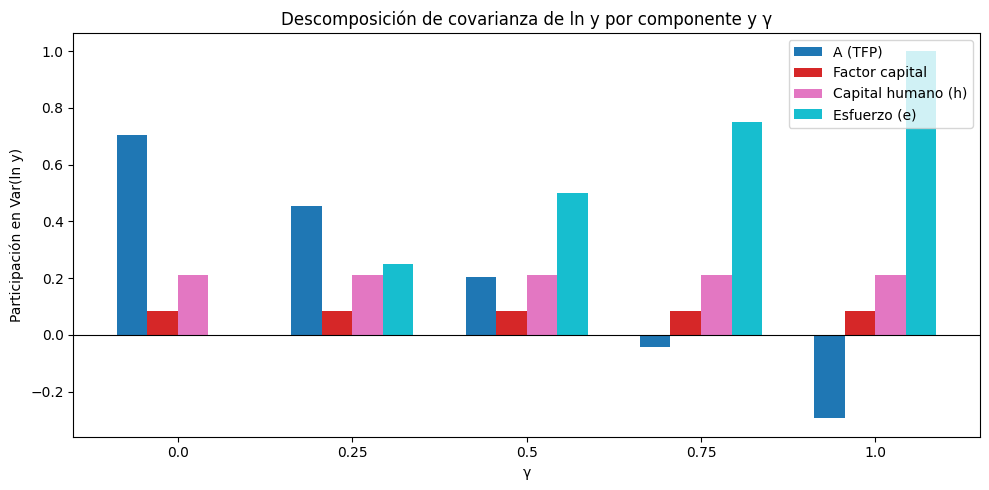

In [6]:
# Gráfico de participaciones θ por γ
theta_df = cov_df[['θ_A', 'θ_fc', 'θ_h', 'θ_e']].copy()
theta_df.columns = ['A (TFP)', 'Factor capital', 'Capital humano (h)', 'Esfuerzo (e)']

ax = theta_df.plot(kind='bar', figsize=(10, 5), colormap='tab10', width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('γ')
ax.set_ylabel('Participación en Var(ln y)')
ax.set_title('Descomposición de covarianza de ln y por componente y γ')
ax.legend(loc='upper right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()